#Importar biblioteca de imagens

In [ ]:
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("lokotwist/shrimp-disease-image-bd")
print("Path to dataset files:", path)

100%|██████████| 204M/204M [00:01<00:00, 108MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lokotwist/shrimp-disease-image-bd/versions/2


#Importar bibliotecas

In [ ]:
from skimage import io, transform
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import os
from PIL import Image

#Padronização das imagens e criação de um data_set

In [ ]:
image_path = "/root/.cache/kagglehub/datasets/lokotwist/shrimp-disease-image-bd/versions/2/Augmented_shrimp"
data = []
label = []

image_size = (128, 128)

def load_image_data(dataset_path, size=image_size):
    images = []
    labels = []

# Percorre cada subpasta (classe)
    for folder_name in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder_name)
        if not os.path.isdir(folder_path):
            continue

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            try:
                # 1. Lê a imagem
                img = cv2.imread(file_path)
                # Verifica se a imagem foi carregada corretamente
                if img is None:
                    print(f"Erro: Não foi possível carregar a imagem {file_path}")
                    continue

                # 2. Redimensiona para tamanho uniforme.
                img_resized = resize(img, size, anti_aliasing=True)

                # 3. Achatamento (Flattening) e adição aos dados
                images.append(img_resized.flatten())
                labels.append(folder_name)
            except Exception as e:
                print(f"Erro carregando {file_path}: {e}")

    return np.array(images), np.array(labels)

In [ ]:
data, labels = load_image_data(os.path.join(path, "Augmented_shrimp"))
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(f"Shape dos dados: {data.shape}") #número de imagens, tamanho
print(f"Shape dos rótulos: {labels_encoded.shape}") #número de imagens, número de classes
print(f"Número de classes: {len(np.unique(labels))}") #número de classes
print(f'Classes: {le.inverse_transform(np.unique(labels_encoded))}')
print(f'imagem por classe: {np.unique(labels, return_counts=True)}')


Shape dos dados: (2000, 49152)
Shape dos rótulos: (2000,)
Número de classes: 4
Classes: ['BG' 'Healthy' 'WSSV' 'WSSV_BG']
imagem por classe: (array(['BG', 'Healthy', 'WSSV', 'WSSV_BG'], dtype='<U7'), array([500, 500, 500, 500]))


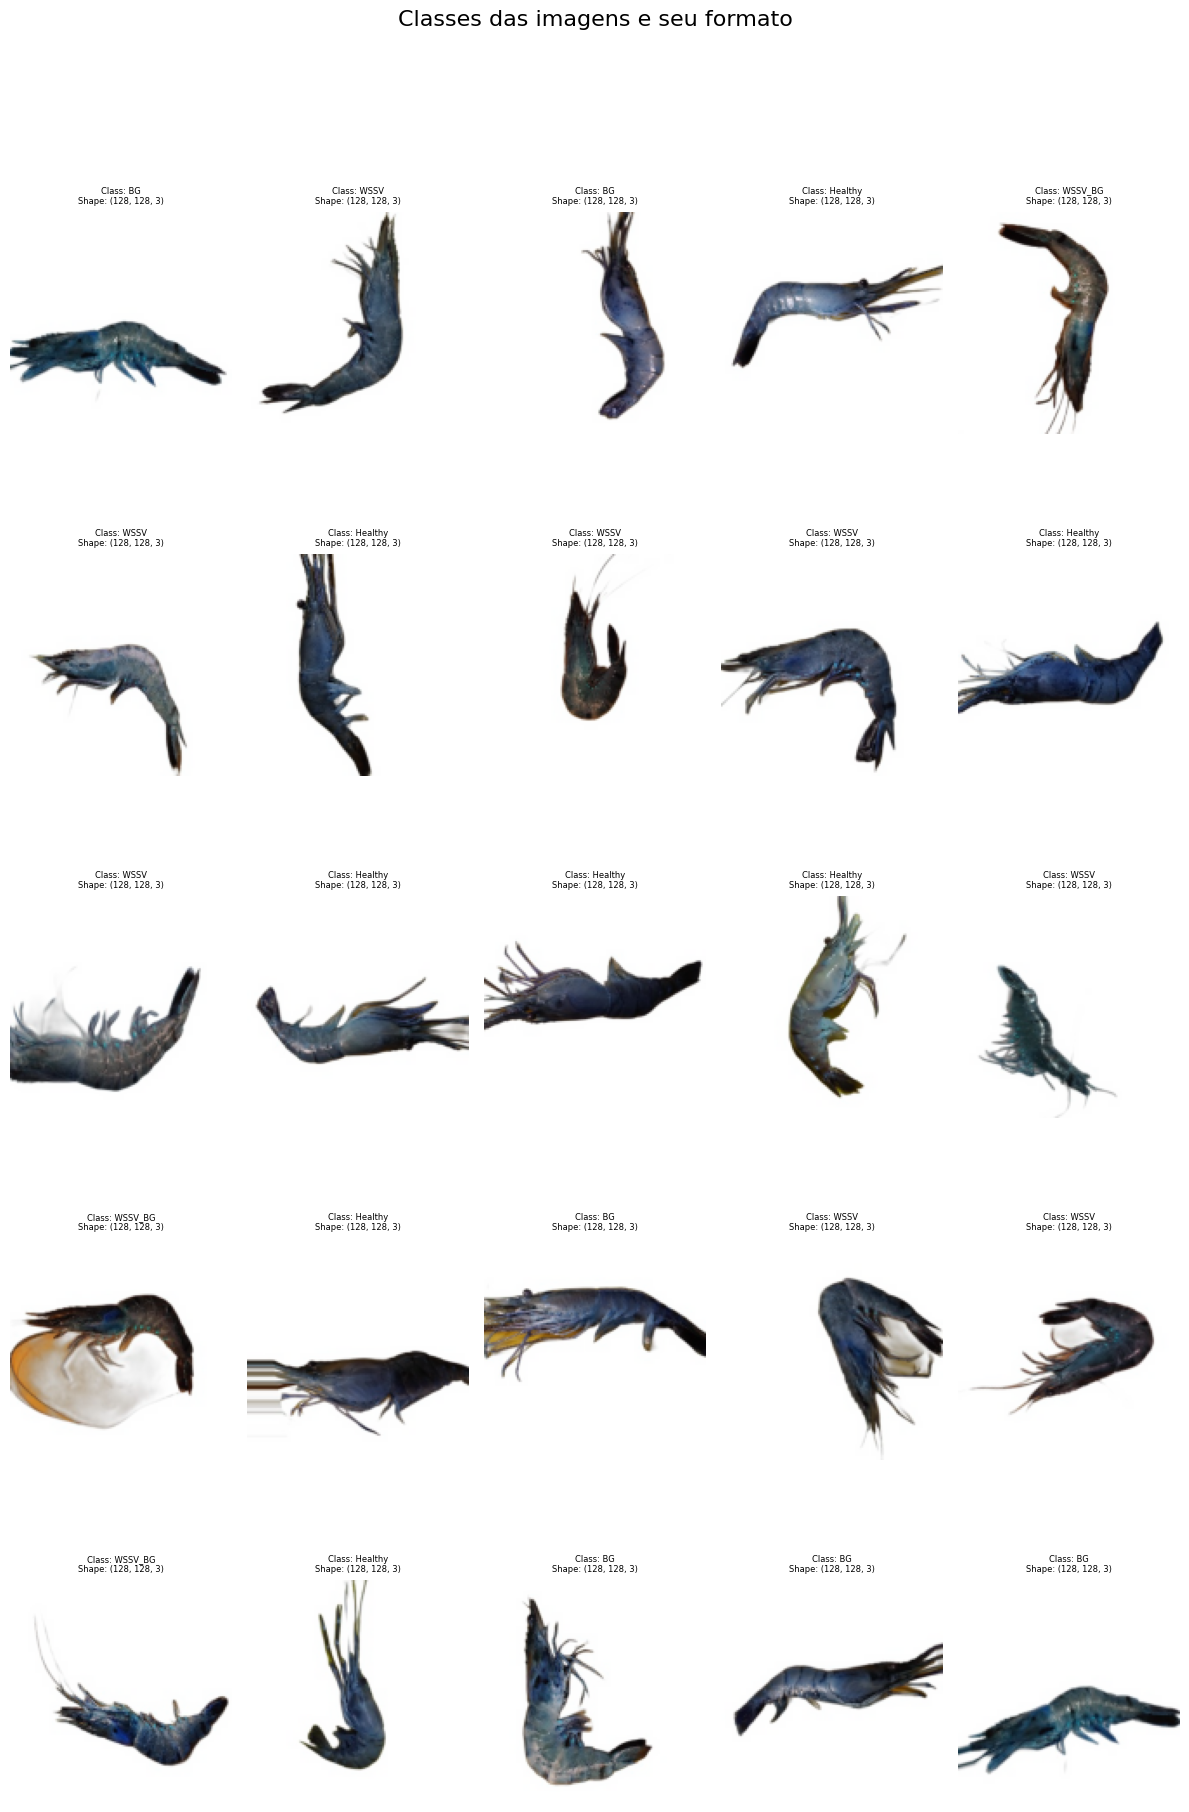

In [ ]:
#Visualização das imagens
import random

fig,ax = plt.subplots(nrows = 5, ncols = 5, figsize = (12,20)) #definiir figuras, coluna e tamanho
fig.suptitle('Classes das imagens e seu formato', fontsize=16)

# Número total de imagens a exibir
total_images_to_display = 5 * 5 # nrows * ncols

# Indicies aleatórios
random_indices = random.sample(range(len(data)), total_images_to_display)

for idx, ax_item in enumerate(ax.flatten()): # Iterate through all subplots
    current_index = random_indices[idx]

    # Imagem flattened
    flat_image = data[current_index]

    # Reshape a imagem para 128, 128 ,3
    image_to_display = flat_image.reshape(128, 128, 3)

    # Rotulando
    image_label = labels[current_index] # Usar o rotulo original

    ax_item.imshow(image_to_display)
    ax_item.set_title(f'Class: {image_label}\nShape: {image_to_display.shape}', fontsize = 6)
    ax_item.axis('off')

fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para subtitulo
fig.show()

#Binários


In [ ]:
y_binary = []
for label_item in labels:
    if label_item == 'Healthy':
        y_binary.append(1)
    else:
        y_binary.append(0)
y_binary = np.array(y_binary)

print(f"Shape of y_binary: {y_binary.shape}")
print(f"First 10 binary labels: {y_binary[:10]}")
print(f"Unique values in y_binary: {np.unique(y_binary, return_counts=True)}")

Shape of y_binary: (2000,)
First 10 binary labels: [1 1 1 1 1 1 1 1 1 1]
Unique values in y_binary: (array([0, 1]), array([1500,  500]))


In [ ]:
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    data, y_binary, test_size=0.2, shuffle=True, random_state=42
)

print(f"Shape of X_train_binary: {X_train_binary.shape}")
print(f"Shape of y_train_binary: {y_train_binary.shape}")
print(f'Shape of X_test_binary: {X_test_binary.shape}')
print(f'Shape of y_test_binary: {y_test_binary.shape}')

Shape of X_train_binary: (1600, 49152)
Shape of y_train_binary: (1600,)
Shape of X_test_binary: (400, 49152)
Shape of y_test_binary: (400,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler_binary = StandardScaler()
X_train_binary_scaled = scaler_binary.fit_transform(X_train_binary.reshape(X_train_binary.shape[0], -1))
X_test_binary_scaled = scaler_binary.transform(X_test_binary.reshape(X_test_binary.shape[0], -1))

print(f"Shape of X_train_binary_scaled: {X_train_binary_scaled.shape}")
print(f"Shape of X_test_binary_scaled: {X_test_binary_scaled.shape}")

Shape of X_train_binary_scaled: (1600, 49152)
Shape of X_test_binary_scaled: (400, 49152)


##SGD


In [ ]:
from sklearn.linear_model import SGDClassifier
from time import perf_counter
sgd_clf_binary = SGDClassifier()
start = perf_counter()
sgd_clf_binary.fit(X_train_binary_scaled, y_train_binary)
end = perf_counter()
tempo_sgd = end - start
print(f"Training time: {tempo_sgd} s")

Training time: 6.5227481340000395 s


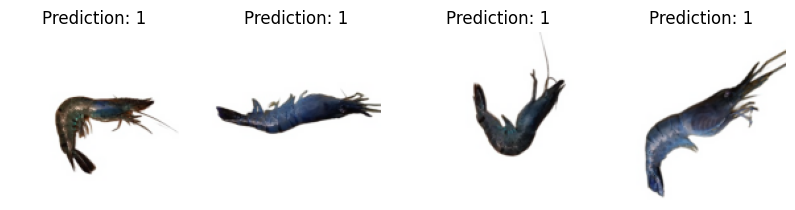

In [ ]:
# Definição da varíavel preditora
predicted_svc = sgd_clf_binary.predict(X_test_binary)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test_binary[:4], predicted_svc[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title(f"Prediction: {prediction}")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_binary = cross_val_predict(sgd_clf_binary,  X_train_binary_scaled, y_train_binary, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.6369
Multiclass Classifier Ponderado Precision: 0.6580
Multiclass Classifier Ponderado Recall: 0.6081
Multiclass Classifier Ponderado F1-score: 0.6275


,Not Healthy,Healthy
Not Healthy,808,396
Healthy,231,165


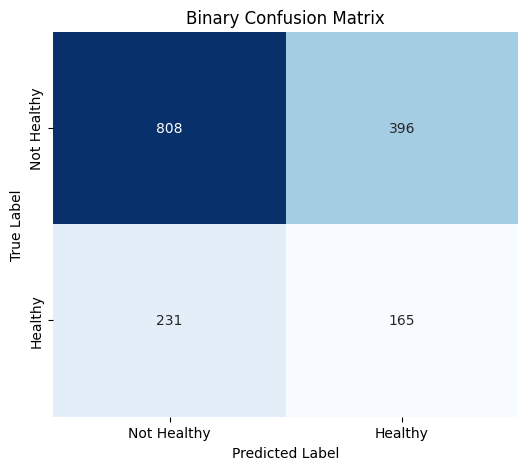

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_sgd_binary = cross_val_score(sgd_clf_binary, X_train_binary_scaled, y_train_binary, cv=3, scoring="accuracy").mean()
precision_sgd_binary = precision_score(y_train_binary, y_train_pred_binary, average='weighted')
recall_sgd_binary = recall_score(y_train_binary, y_train_pred_binary, average='weighted')
f1_sgd_binary = f1_score(y_train_binary, y_train_pred_binary, average='weighted')
roc_sgd_binary = roc_auc_score(y_train_binary, y_train_pred_binary)

print(f'Multiclass Classifier Ponderado Acuracia: {acuracia_sgd_binary:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision_sgd_binary:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_sgd_binary:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_sgd_binary:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_sgd_binary = confusion_matrix(y_train_binary, y_train_pred_binary)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_sgd_binary_df = pd.DataFrame(conf_matrix_sgd_binary, index=binary_labels, columns=binary_labels)
display(conf_matrix_sgd_binary_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_sgd_binary_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###Função de peso

In [ ]:
from sklearn.utils import class_weight

# Calcular os pesos das classes para lidar com o desequilíbrio
# 'balanced' automaticamente calcula pesos inversamente proporcionais às frequências das classes
weights_binary = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_binary),
    y=y_train_binary
)

# Converter os pesos para um dicionário para uso no SGDClassifier
class_weights_dict_binary = dict(zip(np.unique(y_train_binary), weights_binary))

print(f"Pesos calculados para as classes binárias: {class_weights_dict_binary}")

Pesos calculados para as classes binárias: {np.int64(0): np.float64(0.6644518272425249), np.int64(1): np.float64(2.0202020202020203)}


In [ ]:
sgd_clf_binary_weighted = SGDClassifier(class_weight=class_weights_dict_binary)
sgd_clf_binary_weighted.fit(X_train_binary_scaled, y_train_binary)

SGDClassifier(class_weight={np.int64(0): np.float64(0.6644518272425249),
                            np.int64(1): np.float64(2.0202020202020203)})

Binary Classifier Ponderado Acuracia: 0.5544
Binary Classifier Ponderado Precision: 0.3011
Binary Classifier Ponderado Recall: 0.5657
Binary Classifier Ponderado F1-score: 0.3930
Binary Classifier Ponderado ROC AUC Score: 0.5669


,Not Healthy,Healthy
Not Healthy,684,520
Healthy,172,224


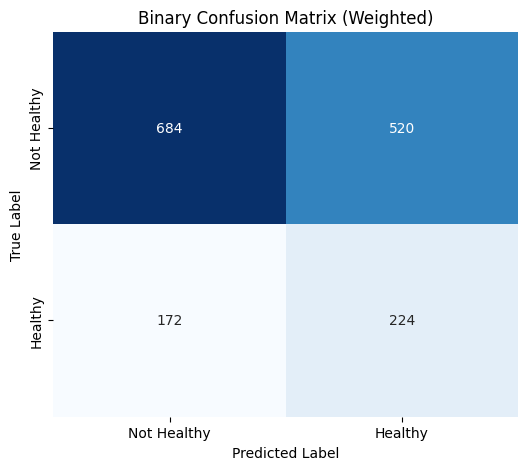

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
y_train_binary_pred_weighted = cross_val_predict(sgd_clf_binary_weighted, X_train_binary_scaled, y_train_binary, cv=3)

acuracia_binary_weighted = cross_val_score(sgd_clf_binary_weighted, X_train_binary_scaled, y_train_binary, cv = 3, scoring = 'accuracy').mean()
precision_binary_weighted = precision_score(y_train_binary, y_train_binary_pred_weighted)
recall_binary_weighted = recall_score(y_train_binary, y_train_binary_pred_weighted)
f1_binary_weighted = f1_score(y_train_binary, y_train_binary_pred_weighted)
roc_auc_score_binary_weighted = roc_auc_score(y_train_binary, y_train_binary_pred_weighted)

print(f"Binary Classifier Ponderado Acuracia: {acuracia_binary_weighted:.4f}")
print(f"Binary Classifier Ponderado Precision: {precision_binary_weighted:.4f}")
print(f"Binary Classifier Ponderado Recall: {recall_binary_weighted:.4f}")
print(f"Binary Classifier Ponderado F1-score: {f1_binary_weighted:.4f}")
print(f"Binary Classifier Ponderado ROC AUC Score: {roc_auc_score_binary_weighted:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_binary_weighted = confusion_matrix(y_train_binary, y_train_binary_pred_weighted)
conf_matrix_df_binary_weighted = pd.DataFrame(conf_matrix_binary_weighted, index=binary_labels, columns=binary_labels)
display(conf_matrix_df_binary_weighted)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_df_binary_weighted, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix (Weighted)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##SVMclassifier

In [ ]:
from sklearn.svm import SVC
from time import perf_counter
svc_clf_binary = SVC()
start = perf_counter()
svc_clf_binary.fit(X_train_binary_scaled, y_train_binary)
end = perf_counter()
tempo_svc = end - start
print(f'Training time: {tempo_svc} s')

Training time: 110.607373483 s


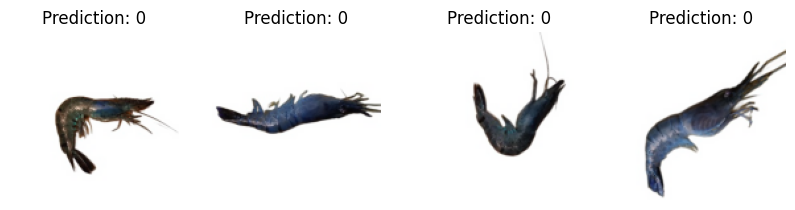

In [ ]:
# Definição da varíavel preditora
predicted_svc_binary = svc_clf_binary.predict(X_test_binary)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test_binary[:4], predicted_svc_binary[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title(f"Prediction: {prediction}")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_svc_binary = cross_val_predict(svc_clf_binary, X_train_binary_scaled, y_train_binary, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.7494
Multiclass Classifier Ponderado Precision: 0.6339
Multiclass Classifier Ponderado Recall: 0.7494
Multiclass Classifier Ponderado F1-score: 0.6481
Multiclass Classifier Ponderado ROC AUC Score: 0.5005


,Not Healthy,Healthy
Not Healthy,1196,8
Healthy,393,3


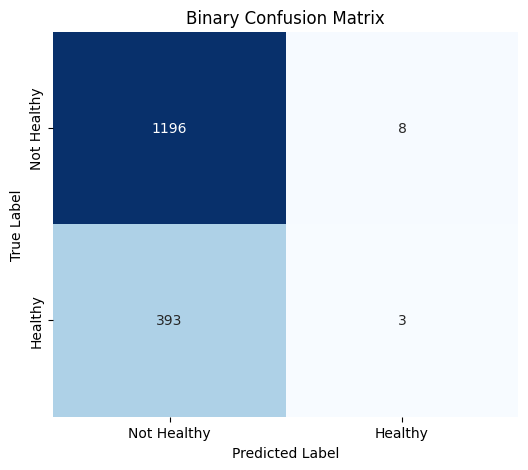

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_svc_binary = cross_val_score(svc_clf_binary, X_train_binary_scaled, y_train_binary, cv=3, scoring="accuracy").mean()
precision_svc_binary = precision_score(y_train_binary, y_train_pred_svc_binary, average='weighted')
recall_svc_binary = recall_score(y_train_binary, y_train_pred_svc_binary, average='weighted')
f1_svc_binary = f1_score(y_train_binary, y_train_pred_svc_binary, average='weighted')
roc_auc_score_svc_binary = roc_auc_score(y_train_binary, y_train_pred_svc_binary)

print(f"Multiclass Classifier Ponderado Acuracia: {acuracia_svc_binary:.4f}")
print(f"Multiclass Classifier Ponderado Precision: {precision_svc_binary:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_binary:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_binary:.4f}")
print(f"Multiclass Classifier Ponderado ROC AUC Score: {roc_auc_score_svc_binary:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_binary = confusion_matrix(y_train_binary, y_train_pred_svc_binary)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_svc_binary_df = pd.DataFrame(conf_matrix_svc_binary, index=binary_labels, columns=binary_labels)
display(conf_matrix_svc_binary_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_binary_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###Funçao Peso

In [ ]:
svc_clf_binary_weighted = SVC(class_weight=class_weights_dict_binary)
svc_clf_binary_weighted.fit(X_train_binary_scaled, y_train_binary)

SVC(class_weight={np.int64(0): np.float64(0.6644518272425249),
                  np.int64(1): np.float64(2.0202020202020203)})

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_binary_svc_weighted = cross_val_predict(sgd_clf_binary_weighted,  X_train_binary_scaled, y_train_binary, cv=3)

Multiclass Classifier Ponderado Acurácia: 0.6944
Multiclass Classifier Ponderado Precision: 0.6723
Multiclass Classifier Ponderado Recall: 0.5800
Multiclass Classifier Ponderado F1-score: 0.6078
Multiclass Classifier Ponderado ROC AUC Score: 0.5633


,Not Healthy,Healthy
Not Healthy,718,486
Healthy,186,210


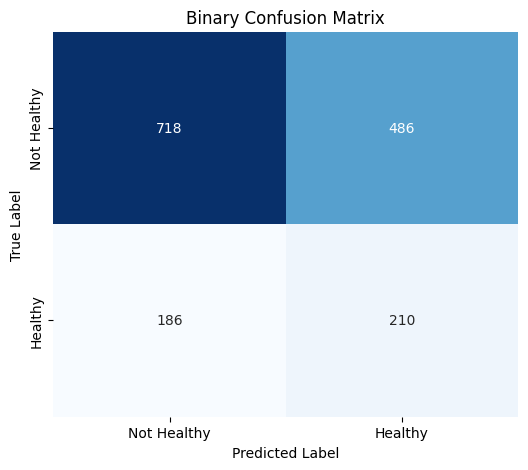

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_svc_binary_weighted = cross_val_score(svc_clf_binary_weighted, X_train_binary_scaled, y_train_binary, cv=3, scoring = 'accuracy').mean()
precision_svc_binary_weighted = precision_score(y_train_binary, y_train_pred_binary_svc_weighted, average='weighted')
recall_svc_binary_weighted = recall_score(y_train_binary, y_train_pred_binary_svc_weighted, average='weighted')
f1_svc_binary_weighted = f1_score(y_train_binary, y_train_pred_binary_svc_weighted, average='weighted')
roc_auc_score_svc_binary_weighted = roc_auc_score(y_train_binary, y_train_pred_binary_svc_weighted)

print(f'Multiclass Classifier Ponderado Acurácia: {acuracia_svc_binary_weighted:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision_svc_binary_weighted:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_binary_weighted:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_binary_weighted:.4f}")
print(f"Multiclass Classifier Ponderado ROC AUC Score: {roc_auc_score_svc_binary_weighted:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_binary_weighted = confusion_matrix(y_train_binary, y_train_pred_binary_svc_weighted)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_svc_binary_df_weighted = pd.DataFrame(conf_matrix_svc_binary_weighted, index=binary_labels, columns=binary_labels)
display(conf_matrix_svc_binary_df_weighted)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_binary_df_weighted, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##SVMclassifier kernel polinear

In [ ]:
from sklearn.svm import SVC
from time import perf_counter
svc_clf_binary_poli = SVC(kernel = 'poly', degree = 3)
start = perf_counter()
svc_clf_binary_poli.fit(X_train_binary_scaled, y_train_binary)
end = perf_counter()
tempo_svc_poli = end - start
print(f'Training time: {tempo_svc_poli} s')

Training time: 122.7885689520001 s


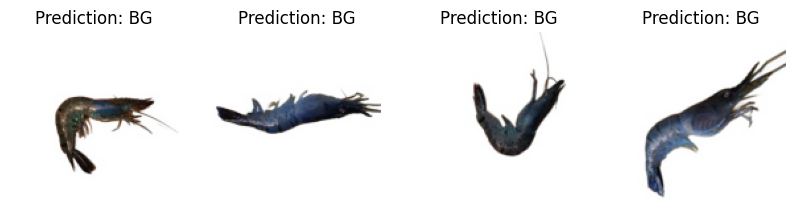

In [ ]:
# Definição da varíavel preditora
predicted_svc_binary_poli = svc_clf_binary_poli.predict(X_test_binary)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test_binary[:4], predicted_svc_binary_poli[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title((f"Prediction: {le.inverse_transform([prediction])[0]}"))
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_svc_binary_poli = cross_val_predict(svc_clf_binary_poli, X_train_binary_scaled, y_train_binary, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.7475
Multiclass Classifier Ponderado Precision: 0.6587
Multiclass Classifier Ponderado Recall: 0.7475
Multiclass Classifier Ponderado F1-score: 0.6557
Multiclass Classifier Ponderado ROC AUC Score: 0.5060


,Not Healthy,Healthy
Not Healthy,1185,19
Healthy,385,11


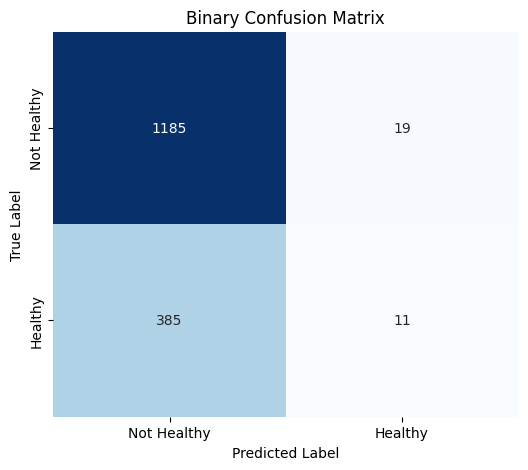

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_svc_binary_poli = cross_val_score(svc_clf_binary_poli, X_train_binary_scaled, y_train_binary, cv=3, scoring = 'accuracy').mean()
precision_svc_binary_poli = precision_score(y_train_binary, y_train_pred_svc_binary_poli, average='weighted')
recall_svc_binary_poli = recall_score(y_train_binary, y_train_pred_svc_binary_poli, average='weighted')
f1_svc_binary_poli = f1_score(y_train_binary, y_train_pred_svc_binary_poli, average='weighted')
roc_auc_score_svc_binary_poli = roc_auc_score(y_train_binary, y_train_pred_svc_binary_poli)

print(f"Multiclass Classifier Ponderado Acuracia: {acuracia_svc_binary_poli:.4f}")
print(f"Multiclass Classifier Ponderado Precision: {precision_svc_binary_poli:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_binary_poli:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_binary_poli:.4f}")
print(f"Multiclass Classifier Ponderado ROC AUC Score: {roc_auc_score_svc_binary_poli:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_binary_poli = confusion_matrix(y_train_binary, y_train_pred_svc_binary_poli)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_svc_binary_df_poli = pd.DataFrame(conf_matrix_svc_binary_poli, index=binary_labels, columns=binary_labels)
display(conf_matrix_svc_binary_df_poli)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_binary_df_poli, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###Função Peso

In [ ]:
svc_clf_binary_poli_weighted = SVC(class_weight=class_weights_dict_binary, kernel = 'poly')
svc_clf_binary_poli_weighted.fit(X_train_binary_scaled, y_train_binary)

SVC(class_weight={np.int64(0): np.float64(0.6644518272425249),
                  np.int64(1): np.float64(2.0202020202020203)},
    kernel='poly')

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_binary_svc_poli_weighted = cross_val_predict(svc_clf_binary_poli_weighted,  X_train_binary_scaled, y_train_binary, cv=3)

Multiclass Classifier Ponderado Precision: 0.6912
Multiclass Classifier Ponderado Recall: 0.7375
Multiclass Classifier Ponderado F1-score: 0.6991
Multiclass Classifier Ponderado ROC AUC Score: 0.5561


,Not Healthy,Healthy
Not Healthy,1102,102
Healthy,318,78


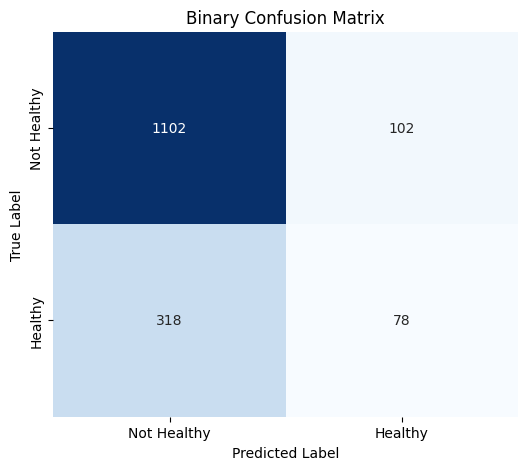

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_svc_binary_poli_weighted = cross_val_score(svc_clf_binary_poli_weighted, X_train_binary_scaled, y_train_binary, cv=3, scoring = 'accuracy').mean()
precision_svc_binary_poli_weighted = precision_score(y_train_binary, y_train_pred_binary_svc_poli_weighted, average='weighted')
recall_svc_binary_poli_weighted = recall_score(y_train_binary, y_train_pred_binary_svc_poli_weighted, average='weighted')
f1_svc_binary_poli_weighted = f1_score(y_train_binary, y_train_pred_binary_svc_poli_weighted, average='weighted')
roc_auc_score_svc_binary_poli_weighted = roc_auc_score(y_train_binary, y_train_pred_binary_svc_poli_weighted)

print(f"Multiclass Classifier Ponderado Precision: {precision_svc_binary_poli_weighted:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_binary_poli_weighted:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_binary_poli_weighted:.4f}")
print(f"Multiclass Classifier Ponderado ROC AUC Score: {roc_auc_score_svc_binary_poli_weighted:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_binary_poli_weighted = confusion_matrix(y_train_binary, y_train_pred_binary_svc_poli_weighted)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_svc_binary_df_poli_weighted = pd.DataFrame(conf_matrix_svc_binary_poli_weighted, index=binary_labels, columns=binary_labels)
display(conf_matrix_svc_binary_df_poli_weighted)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_binary_df_poli_weighted, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##SVMclassifier kernel rbf

In [ ]:
from sklearn.svm import SVC
from time import perf_counter
svc_clf_binary_rbf = SVC(kernel = 'rbf', degree = 3)
start = perf_counter()
svc_clf_binary_rbf.fit(X_train_binary_scaled, y_train_binary)
end = perf_counter()
tempo_svc_rbf = end - start
print(f'Treining time: {tempo_svc_rbf} s')

Treining time: 135.2329313639998 s


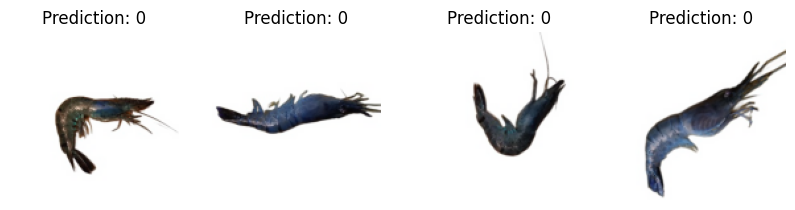

In [ ]:
# Definição da varíavel preditora
predicted_svc_binary_rbf = svc_clf_binary_rbf.predict(X_test_binary)

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
# Display the first 4 images from X_test with their corresponding predictions
for ax, image, prediction in zip(axes, X_test_binary[:4], predicted_svc_binary_rbf[:4]):
    ax.set_axis_off()
    # Reshape the flattened image back to its original dimensions (128, 128, 3)
    ax.imshow(image.reshape(128, 128, 3))
    ax.set_title(f"Prediction: {prediction}")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_svc_binary_rbf = cross_val_predict(svc_clf_binary_rbf, X_train_binary_scaled, y_train_binary, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.7494
Multiclass Classifier Ponderado Precision: 0.6339
Multiclass Classifier Ponderado Recall: 0.7494
Multiclass Classifier Ponderado F1-score: 0.6481
Multiclass Classifier Ponderado ROC AUC Score: 0.5005


,Not Healthy,Healthy
Not Healthy,1196,8
Healthy,393,3


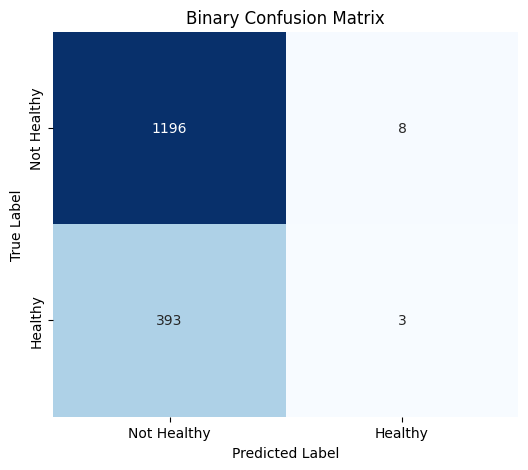

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_svc_binary_rbf = cross_val_score(svc_clf_binary_rbf, X_train_binary_scaled, y_train_binary, cv=3, scoring = 'accuracy').mean()
precision_svc_binary_rbf = precision_score(y_train_binary, y_train_pred_svc_binary_rbf, average='weighted')
recall_svc_binary_rbf = recall_score(y_train_binary, y_train_pred_svc_binary_rbf, average='weighted')
f1_svc_binary_rbf = f1_score(y_train_binary, y_train_pred_svc_binary_rbf, average='weighted')
roc_auc_score_svc_binary_rbf = roc_auc_score(y_train_binary, y_train_pred_svc_binary_rbf)

print(f"Multiclass Classifier Ponderado Acuracia: {acuracia_svc_binary_rbf:.4f}")
print(f"Multiclass Classifier Ponderado Precision: {precision_svc_binary_rbf:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_binary_rbf:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_binary_rbf:.4f}")
print(f"Multiclass Classifier Ponderado ROC AUC Score: {roc_auc_score_svc_binary_rbf:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_binary_rbf = confusion_matrix(y_train_binary, y_train_pred_svc_binary_rbf)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_svc_binary_df_rbf = pd.DataFrame(conf_matrix_svc_binary_rbf, index=binary_labels, columns=binary_labels)
display(conf_matrix_svc_binary_df_rbf)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_binary_df_rbf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###Função Peso

In [ ]:
svc_clf_binary_rbf_weighted = SVC(class_weight=class_weights_dict_binary, kernel = 'rbf')
svc_clf_binary_rbf_weighted.fit(X_train_binary_scaled, y_train_binary)

SVC(class_weight={np.int64(0): np.float64(0.6644518272425249),
                  np.int64(1): np.float64(2.0202020202020203)})

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred_binary_svc_rbf_weighted = cross_val_predict(svc_clf_binary_rbf_weighted,  X_train_binary_scaled, y_train_binary, cv=3)

Multiclass Classifier Ponderado Acuracia: 0.6944
Multiclass Classifier Ponderado Precision: 0.7102
Multiclass Classifier Ponderado Recall: 0.6944
Multiclass Classifier Ponderado F1-score: 0.7013
Multiclass Classifier Ponderado ROC AUC Score: 0.6156


,Not Healthy,Healthy
Not Healthy,929,275
Healthy,214,182


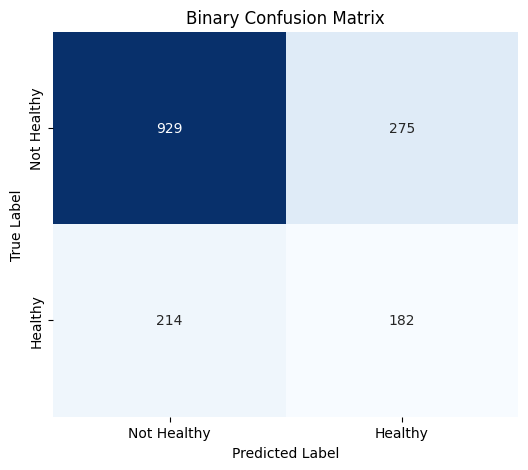

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_svc_binary_rbf_weighted = cross_val_score(svc_clf_binary_rbf_weighted, X_train_binary_scaled, y_train_binary, cv=3, scoring = 'accuracy').mean()
precision_svc_binary_rbf_weighted = precision_score(y_train_binary, y_train_pred_binary_svc_rbf_weighted, average='weighted')
recall_svc_binary_rbf_weighted = recall_score(y_train_binary, y_train_pred_binary_svc_rbf_weighted, average='weighted')
f1_svc_binary_rbf_weighted = f1_score(y_train_binary, y_train_pred_binary_svc_rbf_weighted, average='weighted')
roc_auc_score_svc_binary_rbf_weighted = roc_auc_score(y_train_binary, y_train_pred_binary_svc_rbf_weighted)

print(f'Multiclass Classifier Ponderado Acuracia: {acuracia_svc_binary_rbf_weighted:.4f}')
print(f"Multiclass Classifier Ponderado Precision: {precision_svc_binary_rbf_weighted:.4f}")
print(f"Multiclass Classifier Ponderado Recall: {recall_svc_binary_rbf_weighted:.4f}")
print(f"Multiclass Classifier Ponderado F1-score: {f1_svc_binary_rbf_weighted:.4f}")
print(f"Multiclass Classifier Ponderado ROC AUC Score: {roc_auc_score_svc_binary_rbf_weighted:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_svc_binary_rbf_weighted = confusion_matrix(y_train_binary, y_train_pred_binary_svc_rbf_weighted)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_svc_binary_df_rbf_weighted = pd.DataFrame(conf_matrix_svc_binary_rbf_weighted, index=binary_labels, columns=binary_labels)
display(conf_matrix_svc_binary_df_rbf_weighted)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_svc_binary_df_rbf_weighted, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from time import perf_counter
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1)
start = perf_counter()
rnd_clf.fit(X_train_binary_scaled, y_train_binary)
end = perf_counter()
tempo_rnd = end - start
print(f'Training time: {tempo_rnd} s')


Training time: 39.07166552599938 s


In [ ]:
y_pred_rf = rnd_clf.predict_proba(X_test_binary_scaled)

In [ ]:
from sklearn.model_selection import cross_val_predict
y_pred_hard_rf = rnd_clf.predict(X_test_binary_scaled)

Binary Classifier Ponderado Acuracia: 0.7581
Binary Classifier Ponderado Precision: 0.7844
Binary Classifier Ponderado Recall: 0.7550
Binary Classifier Ponderado F1-score: 0.6671
Binary Classifier Ponderado ROC AUC: 0.8020


,Not Healthy,Healthy
Not Healthy,295,1
Healthy,97,7


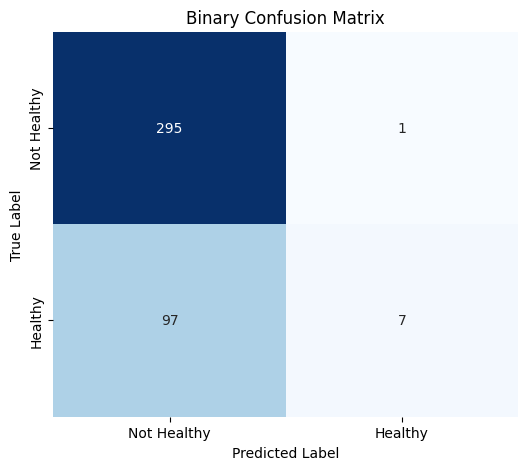

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_rnd = cross_val_score(rnd_clf, X_train_binary_scaled, y_train_binary, cv=3, scoring = 'accuracy').mean()
precision_rnd = precision_score(y_test_binary, y_pred_hard_rf, average='weighted')
recall_rnd = recall_score(y_test_binary, y_pred_hard_rf, average='weighted')
f1_rnd = f1_score(y_test_binary, y_pred_hard_rf, average='weighted')
# For roc_auc_score in binary classification, use probabilities of the positive class
roc_auc_rnd = roc_auc_score(y_test_binary, y_pred_rf[:, 1], average='weighted')

print(f"Binary Classifier Ponderado Acuracia: {acuracia_rnd:.4f}")
print(f"Binary Classifier Ponderado Precision: {precision_rnd:.4f}")
print(f"Binary Classifier Ponderado Recall: {recall_rnd:.4f}")
print(f"Binary Classifier Ponderado F1-score: {f1_rnd:.4f}")
print(f"Binary Classifier Ponderado ROC AUC: {roc_auc_rnd:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_rnd = confusion_matrix(y_test_binary, y_pred_hard_rf)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_rnd_df = pd.DataFrame(conf_matrix_rnd, index=binary_labels, columns=binary_labels)
display(conf_matrix_rnd_df)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rnd_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix') # Updated title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

###Funçao peso

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf_weighted = RandomForestClassifier(class_weight=class_weights_dict_binary,n_estimators=500, max_leaf_nodes=16, n_jobs=-1)
rnd_clf_weighted.fit(X_train_binary_scaled, y_train_binary)

RandomForestClassifier(class_weight={np.int64(0): np.float64(0.6644518272425249),
                                     np.int64(1): np.float64(2.0202020202020203)},
                       max_leaf_nodes=16, n_estimators=500, n_jobs=-1)

In [ ]:
y_pred_rf_weighted = rnd_clf.predict_proba(X_test_binary_scaled)

In [ ]:
from sklearn.model_selection import cross_val_predict
y_pred_hard_rf_weighted = rnd_clf.predict(X_test_binary_scaled)

Binary Classifier Ponderado Precision: 0.7844
Binary Classifier Ponderado Recall: 0.7550
Binary Classifier Ponderado F1-score: 0.6671
Binary Classifier Ponderado ROC AUC: 0.8020


,Not Healthy,Healthy
Not Healthy,295,1
Healthy,97,7


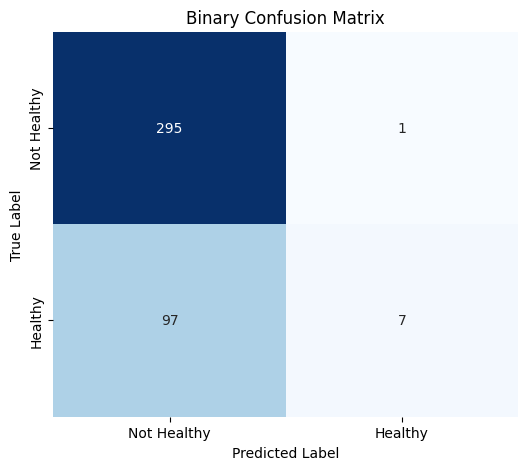

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acuracia_rnd_weighted = cross_val_score(rnd_clf_weighted, X_train_binary_scaled, y_train_binary, cv=3, scoring = 'accuracy').mean()
precision_rnd_weighted = precision_score(y_test_binary, y_pred_hard_rf_weighted, average='weighted')
recall_rnd_weighted = recall_score(y_test_binary, y_pred_hard_rf_weighted, average='weighted')
f1_rnd_weighted = f1_score(y_test_binary, y_pred_hard_rf_weighted, average='weighted')
# For roc_auc_score in binary classification, use probabilities of the positive class
roc_auc_rnd_weighted = roc_auc_score(y_test_binary, y_pred_rf_weighted[:, 1], average='weighted')

print(f"Binary Classifier Ponderado Precision: {precision_rnd:.4f}")
print(f"Binary Classifier Ponderado Recall: {recall_rnd:.4f}")
print(f"Binary Classifier Ponderado F1-score: {f1_rnd:.4f}")
print(f"Binary Classifier Ponderado ROC AUC: {roc_auc_rnd:.4f}")

# Gerar e exibir a nova matriz de confusão
conf_matrix_rnd_weighted = confusion_matrix(y_test_binary, y_pred_hard_rf)

# Define os rótulos para a matriz de confusão binária
binary_labels = ['Not Healthy', 'Healthy'] # 0 e 1, respectivamente

conf_matrix_rnd_df_weighted = pd.DataFrame(conf_matrix_rnd_weighted, index=binary_labels, columns=binary_labels)
display(conf_matrix_rnd_df_weighted)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rnd_df_weighted, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Binary Confusion Matrix') # Updated title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Métricas

##Normal

In [ ]:
indices_line = ['Acurácia', 'Precisão', 'Recall', 'f1-score', 'AUC_ROC']
indices_comlumn = ['SGDClassifier', 'SVMClassifier', 'SVM_kernel:poli', 'SVM_kernel:rbf', 'Random Forest']
acuracia_total = [acuracia_sgd_binary, acuracia_svc_binary, acuracia_svc_binary_poli, acuracia_svc_binary_rbf, acuracia_rnd]
precisao_toal = [precision_sgd_binary, precision_svc_binary, precision_svc_binary_poli, precision_svc_binary_rbf, acuracia_rnd]
recall_total = [recall_sgd_binary, recall_svc_binary, recall_svc_binary_poli, recall_svc_binary_rbf, recall_rnd]
f1_total = [f1_sgd_binary, f1_svc_binary, f1_svc_binary_poli, f1_svc_binary_rbf, f1_rnd]
roc_auc_total = [roc_sgd_binary, roc_auc_score_svc_binary, roc_auc_score_svc_binary_poli, roc_auc_score_svc_binary_rbf, roc_auc_rnd]

metricas = pd.DataFrame(
    [acuracia_total, precisao_toal, recall_total, f1_total, roc_auc_total],
    index=indices_line,
    columns=indices_comlumn
)
metricas

,SGDClassifier,SVMClassifier,SVM_kernel:poli,SVM_kernel:rbf,Random Forest
Acurácia,0.636904,0.749373,0.747503,0.749373,0.758126
Precisão,0.657991,0.633888,0.658720,0.633888,0.758126
Recall,0.608125,0.749375,0.747500,0.749375,0.755000
f1-score,0.627494,0.648110,0.655689,0.648110,0.667093
AUC_ROC,0.543882,0.500466,0.505999,0.500466,0.802008


In [ ]:
indice_tempo = ['Tempo de treinamento (s)']
tempo = [tempo_sgd, tempo_svc, tempo_svc_poli, tempo_svc_rbf, tempo_rnd]
tempo_metricas = pd.DataFrame([tempo], index = indice_tempo, columns = indices_comlumn)
tempo_metricas

,SGDClassifier,SVMClassifier,SVM_kernel:poli,SVM_kernel:rbf,Random Forest
Tempo de treinamento (s),6.522748,110.607373,122.788569,135.232931,39.071666


##Função Peso

In [ ]:
indices_line = ['Acurácia', 'Precisão', 'Recall', 'f1-score', 'AUC_ROC']
indices_comlumn = ['SGDClassifier', 'SVMClassifier', 'SVM_kernel:poli', 'SVM_kernel:rbf', 'Random Forest']
acuracia_total_weighted = [acuracia_binary_weighted, acuracia_svc_binary_weighted, acuracia_svc_binary_poli_weighted, acuracia_svc_binary_rbf_weighted, acuracia_rnd_weighted]
precisao_toal_weighted = [precision_binary_weighted, precision_svc_binary_weighted, precision_svc_binary_poli_weighted, precision_svc_binary_rbf_weighted, acuracia_rnd_weighted]
recall_total_weighted = [recall_binary_weighted, recall_svc_binary_weighted, recall_svc_binary_poli_weighted, recall_svc_binary_rbf_weighted, recall_rnd_weighted]
f1_total_weighted = [f1_binary_weighted, f1_svc_binary_weighted, f1_svc_binary_poli_weighted, f1_svc_binary_rbf_weighted, f1_rnd_weighted]
roc_auc_total_weighted = [roc_auc_score_binary_weighted, roc_auc_score_svc_binary_weighted, roc_auc_score_svc_binary_poli_weighted, roc_auc_score_svc_binary_rbf_weighted, roc_auc_rnd_weighted]

metricas_weighted = pd.DataFrame(
    [acuracia_total_weighted, precisao_toal_weighted, recall_total_weighted, f1_total_weighted, roc_auc_total_weighted],
    index=indices_line,
    columns=indices_comlumn
)
metricas

,SGDClassifier,SVMClassifier,SVM_kernel:poli,SVM_kernel:rbf,Random Forest
Acurácia,0.636904,0.749373,0.747503,0.749373,0.758126
Precisão,0.657991,0.633888,0.658720,0.633888,0.758126
Recall,0.608125,0.749375,0.747500,0.749375,0.755000
f1-score,0.627494,0.648110,0.655689,0.648110,0.667093
AUC_ROC,0.543882,0.500466,0.505999,0.500466,0.802008


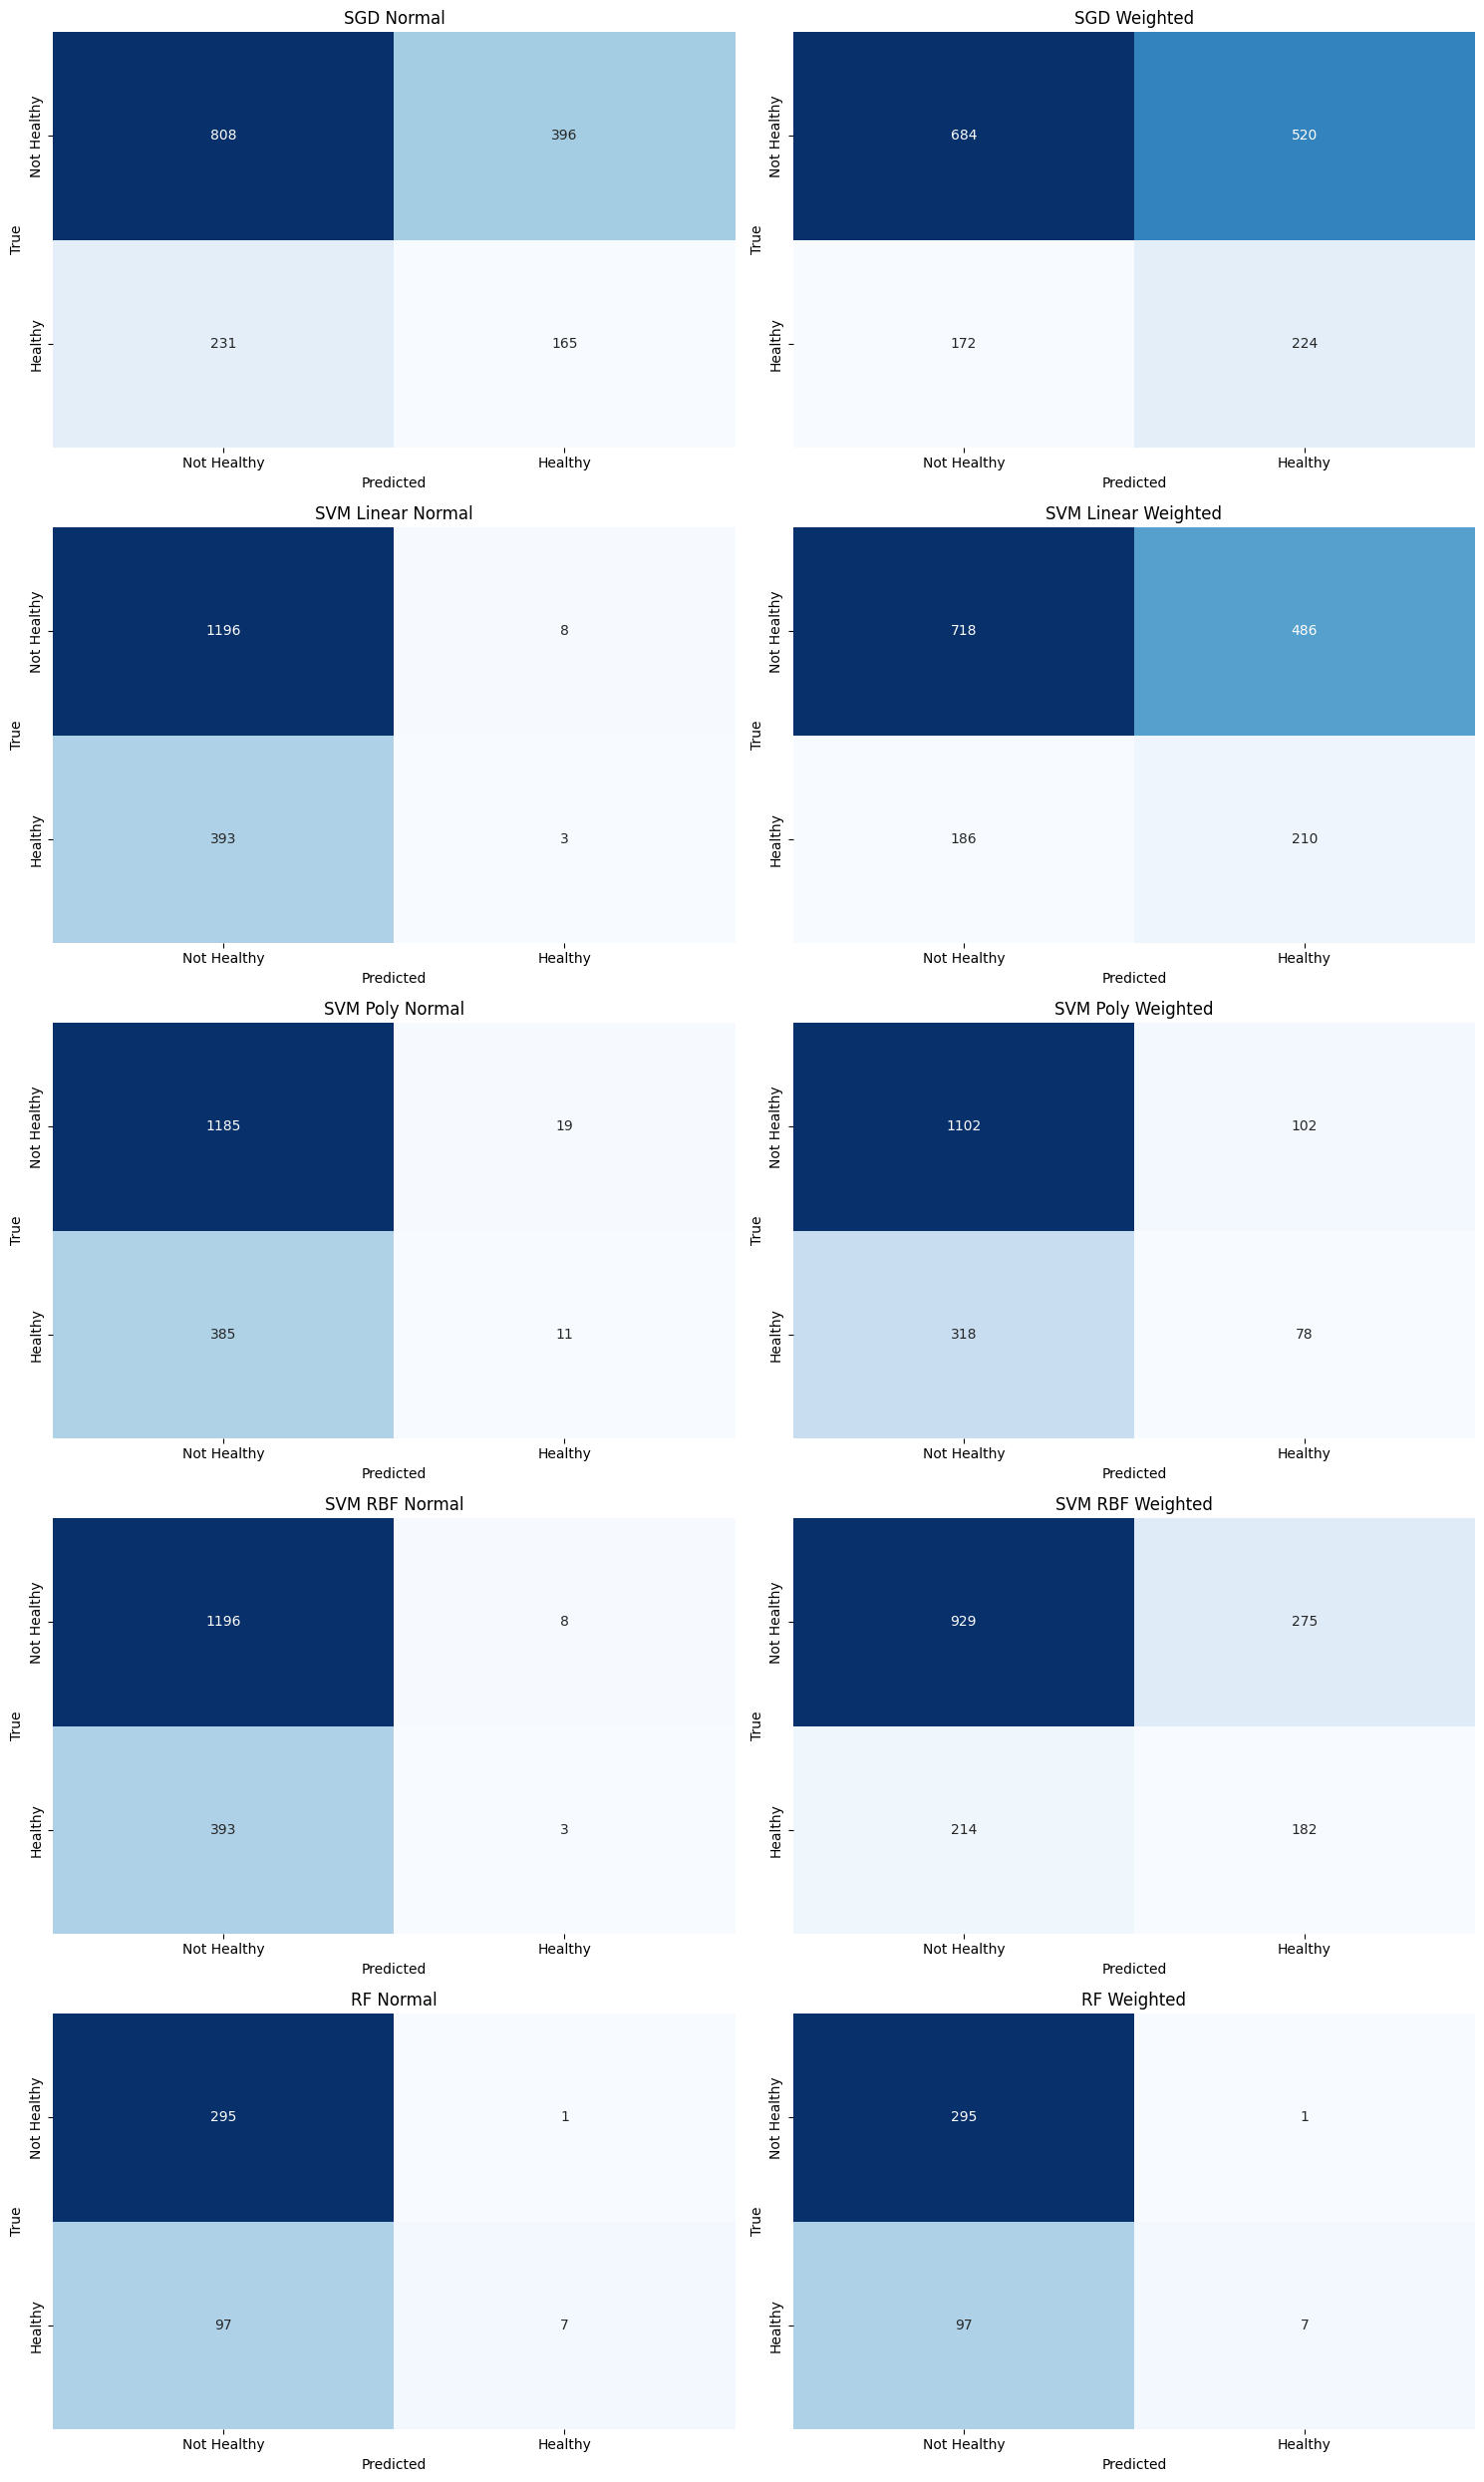

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
confusion_matrices_data = [
    (conf_matrix_sgd_binary, conf_matrix_binary_weighted, 'SGD Normal', 'SGD Weighted'),
    (conf_matrix_svc_binary, conf_matrix_svc_binary_weighted, 'SVM Linear Normal', 'SVM Linear Weighted'),
    (conf_matrix_svc_binary_poli, conf_matrix_svc_binary_poli_weighted, 'SVM Poly Normal', 'SVM Poly Weighted'),
    (conf_matrix_svc_binary_rbf, conf_matrix_svc_binary_rbf_weighted, 'SVM RBF Normal', 'SVM RBF Weighted'),
    (conf_matrix_rnd, conf_matrix_rnd_weighted, 'RF Normal', 'RF Weighted')
]

fig, axes = plt.subplots(5, 2, figsize=(15, 25))

for i, (cm_normal, cm_weighted, title_normal, title_weighted) in enumerate(confusion_matrices_data):
    # Plot normal confusion matrix
    sns.heatmap(pd.DataFrame(cm_normal, index=binary_labels, columns=binary_labels),
                annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i, 0])
    axes[i, 0].set_title(title_normal)
    axes[i, 0].set_xlabel('Predicted')
    axes[i, 0].set_ylabel('True')

    # Plot weighted confusion matrix
    sns.heatmap(pd.DataFrame(cm_weighted, index=binary_labels, columns=binary_labels),
                annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i, 1])
    axes[i, 1].set_title(title_weighted)
    axes[i, 1].set_xlabel('Predicted')
    axes[i, 1].set_ylabel('True')

plt.tight_layout()
plt.show()